# Figure 3 Testing different pruning methods showed differences in network complexity

### B) Comparison of connection probabilities when all pairs are sampled of rat (purple), human (teal) and the analytical model HC RD (black) for the ATC and different pruning methods.

In [3]:
import numpy as np 
import pandas
import conntility as conn
import os
import connalysis
import tqdm

from connalysis.network import classic as nxc

from scipy.spatial import distance
from scipy.spatial.distance import pdist, squareform
from matplotlib import pyplot as plt

#### Global connection probability

In [11]:
# Save the rest of the connectivity matrices in Ms dictionary and load them
root_path = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

fns = {
    "Structural_human": root_path + "Human_NEWstruct_conmat_filtered_compressed.h5",
    "Functional_human": root_path + "Human_NEWfunct_conmat_filtered_compressed.h5",
    "E_to_T_human": root_path + "Human_pruned_E_to_T_conmat.h5",
    "T_to_T_human": root_path + "Human_pruned_T_to_T_conmat.h5",
    "E_to_E_human": root_path + "Human_pruned_E_to_E_conmat.h5",
    "T_to_E_human": root_path + "Human_pruned_T_to_E_conmat.h5",
    "Structural_rat": root_path + "Rat_623um_squared_struc_conmat_filtered_compressed.h5",
    "Functional_rat": root_path + "Rat_623um_squared_funct_conmat_filtered_compressed.h5",
    "E_to_T_rat": root_path + "Rat_pruned_E_to_T_conmat.h5",
    "T_to_T_rat": root_path + "Rat_pruned_T_to_T_conmat.h5",
    "E_to_E_rat": root_path + "Rat_pruned_E_to_E_conmat.h5",
    "T_to_E_rat": root_path + "Rat_pruned_T_to_E_conmat.h5",
    "E_to_T_HC_RD": root_path + "humanized_rat_pruned_E_to_T_conmat.h5",
    "T_to_T_HC_RD": root_path + "humanized_rat_pruned_T_to_T_conmat.h5",
    "E_to_E_HC_RD": root_path + "humanized_rat_pruned_E_to_E_conmat.h5",
    "T_to_E_HC_RD": root_path + "humanized_rat_pruned_T_to_E_conmat.h5"
}
Ms = dict([(k, conn.ConnectivityMatrix.from_h5(v))
           for k, v in fns.items()])

In [12]:
# Control matrix have a special group_name
Ms["HC_RD"] = conn.ConnectivityMatrix.from_h5(root_path+"third_order_mdl_instances_humanized_rat.h5", "instance1")

In [13]:
Ms_key_list = list(Ms.keys())
Ms_key_list

['Structural_human',
 'Functional_human',
 'E_to_T_human',
 'T_to_T_human',
 'E_to_E_human',
 'T_to_E_human',
 'Structural_rat',
 'Functional_rat',
 'E_to_T_rat',
 'T_to_T_rat',
 'E_to_E_rat',
 'T_to_E_rat',
 'E_to_T_HC_RD',
 'T_to_T_HC_RD',
 'E_to_E_HC_RD',
 'T_to_E_HC_RD',
 'HC_RD']

#### Compute global connection probability

In [14]:
density = {}

Ms_key_list = list(Ms.keys())
for k in Ms_key_list:
    adj_mat = Ms[k].matrix
    dens = nxc.density(adj_mat,neuron_properties=[])
    density[k] = dens

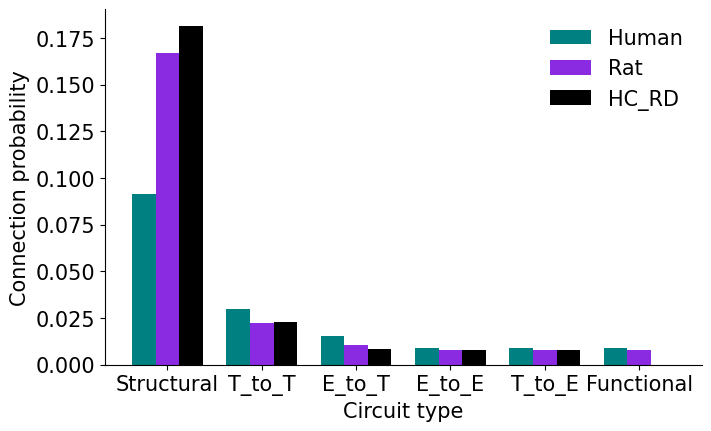

In [15]:
circ_types = ("Structural", "T_to_T", "E_to_T", "E_to_E", "T_to_E", "Functional")
color = ("teal", "blueviolet", "black")
values = {
    'Human': (density['Structural_human'], density['T_to_T_human'], density['E_to_T_human'], density['E_to_E_human'], density['T_to_E_human'], density['Functional_human']),
    'Rat': (density['Structural_rat'], density['T_to_T_rat'], density['E_to_T_rat'], density['E_to_E_rat'], density['T_to_E_rat'], density['Functional_rat']),
    'HC_RD': (density['HC_RD'], density['T_to_T_HC_RD'], density['E_to_T_HC_RD'], density['E_to_E_HC_RD'], density['T_to_E_HC_RD'], 0.0)
}

x = np.arange(len(circ_types))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(7, 4.2))

for c, (attribute, measurement) in zip(color, values.items()):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=c)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.spines[['right', 'top']].set_visible(False)
ax.set_ylabel('Connection probability', fontsize=15)
ax.set_xlabel('Circuit type', fontsize=15)
#ax.set_title('Connection Probability')
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xticks(x + width, circ_types)
ax.legend(loc='upper right', ncols=1, fontsize=15, frameon=False)


plt.show()